# Tutorial 01: Data Loading Basics

## Overview

`Data_Set` is the container for everything observational. This tutorial covers loading
data into it — from the manyTDE database, or from your own arrays — plotting it,
cleaning it, and saving the result.

## Learning Objectives

By the end of this tutorial, you will:

- Understand what a `Data_Set` holds and how it is organised
- Be able to load photometry by IAU name from manyTDE
- Be able to load your own rest-frame data
- Know how to plot, cut and rebin
- Know how to save a cleaned data set and load it back

## Prerequisites

- **Tutorial 00: Introduction and Installation**

## A terminology warning

FitTeD splits observations into two kinds, and the names are not what you would guess:

- **"UV"** means *monochromatic* — a measurement at a single frequency. Optical,
  ultraviolet and near-infrared photometry are all "UV" in this sense.
- **"X"** means *integrated over a band* — a measurement summed across an energy range.
  X-ray photometry is the case that matters.

So `bands_UV` will contain your ZTF *r*-band, and `args_X` will contain your Swift XRT
0.3–10 keV points. The distinction is about how the model must be integrated to compare
with the measurement, not about wavelength. It is used consistently throughout the
codebase, so it is worth ten seconds of getting used to.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# If FitTeD was installed with `pip install -e .` this block is unnecessary.
# It is here so the notebooks also work from a bare checkout.
package_dir = Path().resolve().parent
if str(package_dir) not in sys.path:
    sys.path.append(str(package_dir))   # append, so an installed copy wins

import fitted
fitted.format_plots()

print("FitTeD", fitted.__version__)


  _____  _  _   _____      ____   
 |  ___|(_)| |_|_   _|___ |  _ \  
 | |_   | || __| | | / _ \| | | | 
 |  _|  | || |_  | ||  __/| |_| | 
 |_|    |_| \__| |_| \___||____/  
                                  
   FITing TransiEnts with Discs   

 Version 2.0.0
 manyTDE compatible?  Yes

 FitTeD was created by Andrew Mummery* and Edward Nathan$.

 Please cite us if you make use of this code
 https://ui.adsabs.harvard.edu/abs/2025MNRAS.544.2225M/abstract

 * amummery@ias.edu
 $ edward.j.r.nathan@gmail.com




FitTeD 2.0.0


## Loading from manyTDE

If manyTDE is installed, one line gets you the photometry of any TDE in its catalogue,
already converted to rest-frame νL_ν with the redshift and distance filled in.

```python
Data_Set(
    manyTDE_name='AT2019dsg',
    manyTDE_bands=['r.ztf', 'g.ztf', 'UVW1.uvot'],
    global_systematic=0.1,
)
```

- `manyTDE_name` — IAU name
- `manyTDE_bands` — which filters to pull. ZTF: `g.ztf`, `r.ztf`, `i.ztf`.
  Swift/UVOT: `UVW1.uvot`, `UVW2.uvot`, `UVM2.uvot`, `U.uvot`, `B.uvot`, `V.uvot`.
  Pan-STARRS: `g.ps`, `r.ps`, `i.ps`. SDSS: `u.sdss`, `g.sdss`, `r.sdss`, `i.sdss`.
- `global_systematic` — adds this fraction of the luminosity to every uncertainty. For
  TDEs, 0.1 is a common choice; it encodes the fact that a smooth disc model is not
  expected to match the data to ZTF's photometric precision.

If a requested band is not in the catalogue for that object, FitTeD tells you which
bands *are* available and carries on with the rest.

In [2]:
have_manyTDE = fitted.data.manyTDE_available == "Yes"

if have_manyTDE:
    data_set = fitted.data.Data_Set(
        manyTDE_name='AT2019dsg',
        manyTDE_bands=['r.ztf', 'g.ztf', 'UVW1.uvot', 'UVW2.uvot', 'UVM2.uvot'],
        global_systematic=0.1,
    )
    print("redshift          %.4f" % data_set.redshift)
    print("luminosity dist.  %.1f Mpc" % data_set.d_Mpc)
    print("\n%-14s %7s   %s" % ("band", "points", "rest-frame days"))
    for band in data_set.bands_UV:
        t = data_set.args_band[band][0]
        print("%-14s %7d   %.0f to %.0f"
              % (band, len(t), t.min(), t.max()))
else:
    data_set = None
    print("manyTDE is not installed, so this section is skipped.")
    print("Install it with:")
    print("  git clone https://github.com/sjoertvv/manyTDE")
    print("  cd manyTDE && python3 -m pip install -e .")
    print("\nEverything else in this tutorial runs without it.")

redshift          0.0512
luminosity dist.  235.6 Mpc

band            points   rest-frame days
r.ztf              734   -375 to 2060
g.ztf              468   -375 to 2060
UVW1.uvot           36   16 to 1882
UVW2.uvot           39   16 to 1882
UVM2.uvot           37   16 to 1882


Note the negative times. manyTDE reports times relative to the flare peak, so the ZTF
light curves include a long pre-flare baseline. That is real data and worth keeping
until you have looked at it — but see the cleaning section below.

## Loading your own data

If your object is not in manyTDE, or you have data manyTDE does not, pass arrays
directly. Everything must be in the **rest frame** (Tutorial 02 covers observer-frame
input, where FitTeD does the conversions for you).

```python
Data_Set(
    args_UV=[[times, lums, errs, freq], ...],   # one entry per band
    bands_UV=['g.custom', ...],
    args_X=[[times, lums, errs, [E_lo, E_hi]], ...],
    bands_X=['Swift XRT', ...],
    args_UV_upperlim=..., bands_UV_upperlim=...,
    args_X_upperlim=..., bands_X_upperlim=...,
    global_systematic=0.1,
)
```

For monochromatic (`UV`) data each entry is `[times, luminosities, uncertainties,
frequency]` — times in rest-frame days, νL_ν and its uncertainty in erg/s, frequency in
Hz. For band-integrated (`X`) data the last element is `[E_low, E_high]` in rest-frame
keV, and the luminosities are integrated over that band in erg/s.

Upper limits take the same shape, except the third element is the **number of sigma**
the limit represents rather than an uncertainty.

Here is the real Swift XRT light curve of AT2019dsg, which ships with the package as
observed fluxes.

In [3]:
from astropy import units

xray_file = package_dir / 'fitted' / 'examples' / '2019dsg_Xray.txt'
D_Mpc = 236.4

raw = np.genfromtxt(xray_file, skip_header=3)
kind = np.genfromtxt(xray_file, skip_header=3, usecols=(1), dtype=str)

# The file holds fluxes; FitTeD wants luminosities.
scale = 4 * np.pi * (D_Mpc * units.Mpc.to(units.cm))**2
det, lim = kind == 'X', kind == 'XUL'

data_xray = fitted.data.Data_Set(
    args_X=[[raw[:, 0][det], raw[:, 2][det] * scale,
             raw[:, 3][det] * scale, [0.3, 10]]],
    bands_X=['Swift XRT'],
    args_X_upperlim=[[raw[:, 0][lim], raw[:, 2][lim] * scale,
                      3 * np.ones(lim.sum()),       # 3-sigma limits
                      [0.3, 10]]],
    bands_X_upperlim=['Swift XRT upper limit'],
)

print("X-ray bands:  ", data_xray.bands_X)
print("detections:   %d" % len(data_xray.args_band['Swift XRT'][0]))
print("upper limits: %d" % len(data_xray.args_band['Swift XRT upper limit'][0]))

X-ray bands:   ['Swift XRT']
detections:   10
upper limits: 14


Upper limits are not decoration. Fourteen of the twenty-four X-ray epochs here are
non-detections, and they are what stops a model from predicting bright early X-rays
that were not seen. They enter the likelihood as one-sided constraints.

## Plotting

`plot_data()` gives you every band in one figure.

```python
fig = data_set.plot_data(
    bands=None,          # None = all bands
    yscale='log', xscale='linear',
    ylim=None, xlim=None,
    ylabel=r'$L$ [erg/s]', xlabel=r'Time [days]',
    fig=None,            # pass an existing figure to overlay
)
```

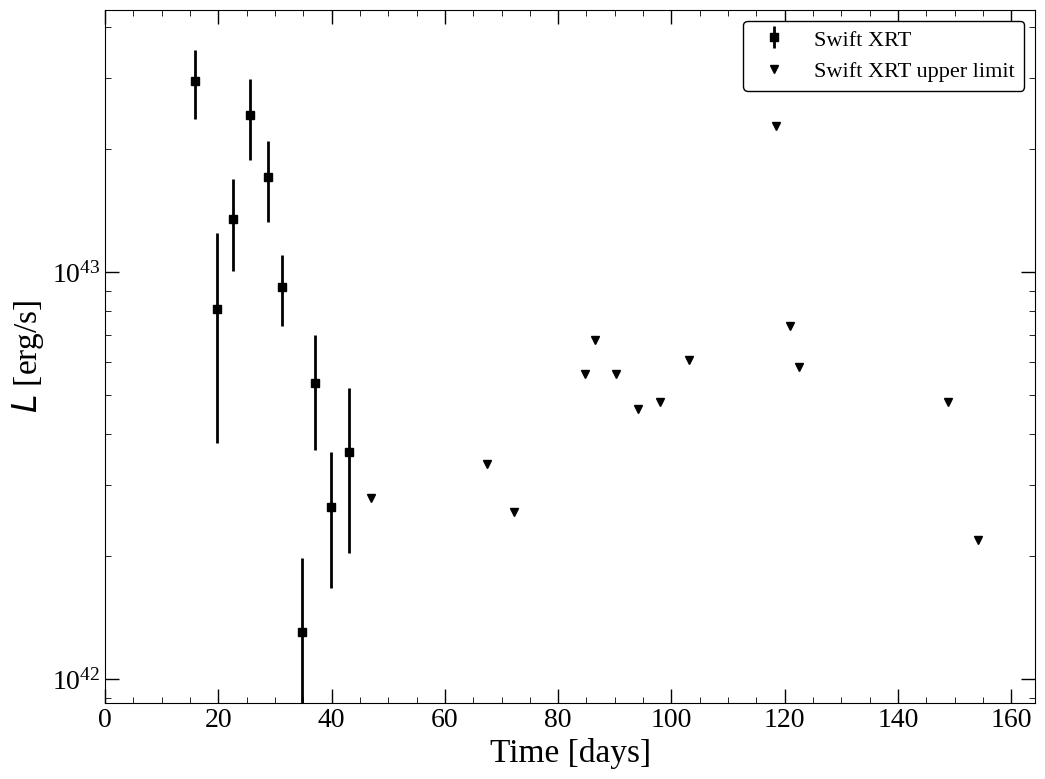

In [4]:
fig = data_xray.plot_data()
plt.show()

## Cleaning

Four methods, all operating on one band at a time:

| Method | What it does |
|--------|--------------|
| `remove_before_time(band, t_start)` | drop points earlier than `t_start` |
| `remove_after_time(band, t_end)` | drop points later than `t_end` |
| `remove_cut(band, t_start, t_end)` | drop points inside a window |
| `rebin_band(band, delta_t, t_start=None, t_end=None)` | bin into `delta_t`-day bins |

`rebin_band` combines points with inverse-variance weighting, so it does not throw
information away — it trades time resolution you do not need for a smaller, better
conditioned data set.

**Why rebin at all?** Because cadence is not information. A ZTF light curve may have
700 points in the first month and twenty over the following two years. Left alone, the
first month dominates the likelihood purely by weight of numbers, and the late-time
behaviour — which is where the disc actually shows itself — gets outvoted. Rebinning
early data finely and late data coarsely fixes the imbalance.

In [5]:
if have_manyTDE:
    before = {b: (len(data_set.args_band[b][0]),
                  data_set.args_band[b][0].copy(),
                  data_set.args_band[b][1].copy())
              for b in data_set.bands_UV}

    for band in data_set.bands_UV:
        data_set.remove_before_time(band, t_start=-50)   # drop pre-flare baseline
        data_set.remove_after_time(band, t_end=1000)     # host subtraction dominates later
        data_set.rebin_band(band, delta_t=10, t_end=100)    # dense early coverage
        data_set.rebin_band(band, delta_t=50, t_start=100)  # sparse late coverage

    print("%-14s %8s %8s" % ("band", "before", "after"))
    for band in data_set.bands_UV:
        print("%-14s %8d %8d"
              % (band, before[band][0], len(data_set.args_band[band][0])))
else:
    before = None
    print("Skipped (needs manyTDE).")

band             before    after
r.ztf               734       26
g.ztf               468       22
UVW1.uvot            36       13
UVW2.uvot            39       13
UVM2.uvot            37       13


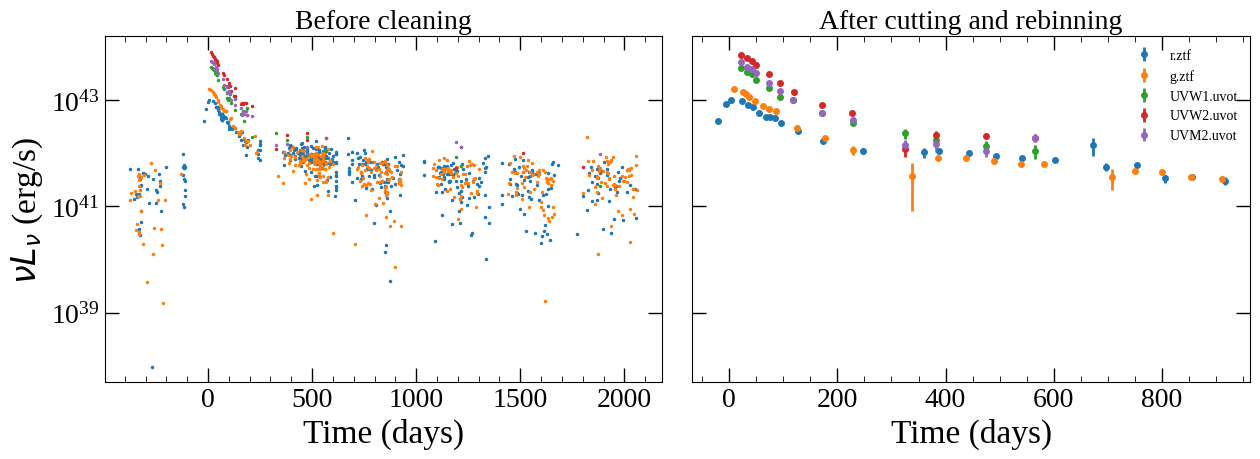

In [6]:
if have_manyTDE:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
    for i, band in enumerate(data_set.bands_UV):
        ax1.plot(before[band][1], before[band][2], '.', ms=3,
                 color='C%d' % i, label=band)
        t, L, e = data_set.args_band[band]
        ax2.errorbar(t, L, yerr=e, fmt='o', ms=4, color='C%d' % i, label=band)
    ax1.set(xlabel='Time (days)', ylabel=r'$\nu L_\nu$ (erg/s)', yscale='log',
            title='Before cleaning')
    ax2.set(xlabel='Time (days)', title='After cutting and rebinning')
    ax2.legend(frameon=False, fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("Skipped (needs manyTDE).")

The cleaned version is not a prettier version of the same thing — it is a different
statistical object, with the early and late epochs carrying comparable weight. Choose
the cuts deliberately, write them down, and check at the end that your result does not
depend on them (Tutorial 10 says more about this).

## Saving and loading

```python
data_set.save('my_object')      # writes my_object_DATA.pickle

loaded = fitted.data.Data_Set()
loaded.load('my_object')
```

`save()` appends `_DATA` to the name and pickles the object. Worth doing once the
cleaning is settled, so that a fit always starts from exactly the same data.

In [7]:
import os

data_xray.save('tutorial_example')
print("saved:", os.path.basename('tutorial_example_DATA.pickle'),
      "(%d bytes)" % os.path.getsize('tutorial_example_DATA.pickle'))

reloaded = fitted.data.Data_Set()
reloaded.load('tutorial_example')
print("reloaded bands:", reloaded.bands_X)

t_a = data_xray.args_band['Swift XRT'][0]
t_b = reloaded.args_band['Swift XRT'][0]
print("round trip exact:", np.array_equal(t_a, t_b))

os.remove('tutorial_example_DATA.pickle')

saved: tutorial_example_DATA.pickle (1327 bytes)
reloaded bands: ['Swift XRT']
round trip exact: True


## Summary

- `Data_Set` holds monochromatic (`UV`) and band-integrated (`X`) data, detections and
  upper limits, plus redshift and distance.
- `manyTDE_name` loads published TDE photometry by IAU name.
- `args_UV` / `args_X` take your own rest-frame arrays; upper limits use a sigma count
  in place of an uncertainty.
- Cut and rebin deliberately — cadence is not information.
- `save()` / `load()` freeze a cleaned data set.

## Next steps

- **Tutorial 02: Observer-Frame Data Input** — let FitTeD do the cosmology
- **Tutorial 03: Model Setup and Parameters** — build a model to fit this data

## Further reading

- **Paper Section 3**: data handling (arXiv:2408.15048)
- `fitted/examples/data_loading.py`